# Retrieval-Augmented Generation

## Setting up the LLM

In [ ]:
!pip install --upgrade langchain
!pip install --upgrade langchain-core
!pip install --upgrade langchain-community
!pip install --upgrade langchain-google-genai

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
help(ChatGoogleGenerativeAI)

In [ ]:
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI

chat_model = ChatGoogleGenerativeAI(model="gemini-1.5-flash",
                                  temperature=0,
                                  google_api_key=userdata.get('GOOGLE_API_KEY'))

#### First Test

In [ ]:
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, SystemMessage

# 1. Initialize the Chat Model (from the previous step)
chat_model = ChatGoogleGenerativeAI(model="gemini-2.5-flash",
                                  temperature=0,
                                  google_api_key=userdata.get('GOOGLE_API_KEY'))

# 2. Prepare the messages
# The SystemMessage sets the behavior and context for the AI.
# The HumanMessage is the user's actual query.
messages = [
    SystemMessage(content="You're an assistant knowledgeable about healthcare. Only answer healthcare-related questions."),
    HumanMessage(content="What is Ayushman Bharat?"),
]

# 3. Invoke the model with the messages
result = chat_model.invoke(messages) # notice the similarity with model.predict from sklearn

print(result.content)

In [ ]:
chat_model.invoke("What is blood pressure?")

#### Second Test

In [ ]:
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, SystemMessage

# 1. Initialize the Chat Model
chat_model = ChatGoogleGenerativeAI(model="gemini-1.5-flash",
                                  temperature=0,
                                  google_api_key=userdata.get('GOOGLE_API_KEY'))

# 2. Prepare messages with an out-of-scope question
messages = [
    SystemMessage(content="You're an assistant knowledgeable about healthcare. Only answer healthcare-related questions."),
    HumanMessage(content="How do I change a tire?"),
]

# 3. Invoke the model
result = chat_model.invoke(messages)

print(result.content)

## ChatPromptTemplate

In [ ]:
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 1. Initialize the Chat Model
chat_model = ChatGoogleGenerativeAI(model="gemini-2.5-flash",
                                  temperature=0,
                                  google_api_key=userdata.get('GOOGLE_API_KEY'))

# 2. Create the Prompt Template
instruction_str = """Your job is to use patient reviews to answer questions about their experience at a hospital.
Use the following context to answer questions. Be as detailed as possible, but don't make up any information that's not from the context.
If you don't know an answer, say you don't know.

Context: {context}

Question: {question}
"""

review_template = ChatPromptTemplate.from_template(instruction_str)

# 3. Define the context and question
context = "The discharge process was seamless!"
question = "Did anyone have a positive experience?"

# 4. Create the chain by piping the components together
#    We also add an output parser to get a clean string result.
chain = review_template | chat_model | StrOutputParser()

# 5. Invoke the chain with the input variables
result = chain.invoke({
    "context": context,
    "question": question
})

print(result)

## Using PromptTemplates & MessageTemplates

In [ ]:
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import (
    PromptTemplate,
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate,
    ChatPromptTemplate
)
from langchain_core.output_parsers import StrOutputParser

# 1. Initialize the Chat Model
chat_model = ChatGoogleGenerativeAI(model="gemini-2.5-flash",
                                  temperature=0,
                                  google_api_key=userdata.get('GOOGLE_API_KEY'))

# 2. Create the detailed prompt templates
instruction_str = """Your job is to use patient reviews to answer questions about their experience at a hospital.
Use the following context to answer questions.
Be as detailed as possible, but don't make up any information that's not from the context.
If you don't know an answer, say you don't know.

Context: {context}
"""

review_system_prompt = SystemMessagePromptTemplate(
    prompt=PromptTemplate(
        input_variables=["context"], template=instruction_str
    )
)

review_human_prompt = HumanMessagePromptTemplate(
    prompt=PromptTemplate(
        input_variables=["question"], template="{question}"
    )
)

messages = [review_system_prompt, review_human_prompt]

# This is our final, reusable prompt template
review_prompt_template = ChatPromptTemplate(
    input_variables=["context", "question"],
    messages=messages,
)

# 3. Define the context and question
context = "I had a great stay!"
question = "Did anyone have a positive experience?"

# 4. Create the chain
chain = review_prompt_template | chat_model | StrOutputParser()

# 5. Invoke the chain
result = chain.invoke({
    "context": context,
    "question": question
})

print(result)

In [ ]:
context = "I had a negative stay!"
question = "Did anyone have a positive experience?"

chain.invoke({"context": context, "question": question})

# Adding RAG

In [ ]:
!pip install -U langchain-chroma # FAISS

In [ ]:
import time
from google.colab import userdata

# Import the CSVLoader class to load documents from a CSV file.
from langchain.document_loaders.csv_loader import CSVLoader

# Import the Chroma class, which is used to create and interact with a Chroma vector database.
from langchain_chroma import Chroma

# Import the GoogleGenerativeAIEmbeddings class to create numerical vector representations (embeddings) of text using Google's models.
from langchain_google_genai import GoogleGenerativeAIEmbeddings


REVIEWS_CSV_PATH = "/content/reviews.csv"

# Define a constant variable for the directory where the Chroma vector database will be stored.
REVIEWS_CHROMA_PATH = "chroma_data"


# Create an instance of the CSVLoader.
loader = CSVLoader(
    file_path=REVIEWS_CSV_PATH,  # Specify the path to the CSV file to be loaded.
    source_column="review"       # Specify the name of the column that contains the main text content.
)

# Call the .load() method on the loader instance.
# This reads the specified column from the CSV file and loads the content into a list of Document objects.
reviews = loader.load()

# Specify the embedding function to use. We define it once to be reused.
embedding_function = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",  # Choose the specific embedding model provided by Google.
    google_api_key=userdata.get('GOOGLE_API_KEY')  # Securely fetch the Google API key.
)

# Set the size of each batch to process.
batch_size = 20
# Calculate the total number of batches.
num_batches = (len(reviews) - 1) // batch_size + 1
reviews_vector_db = None

# Loop through the documents in batches to avoid hitting the API's rate limit.
for i in range(0, len(reviews), batch_size):
    # Get the current batch of documents.
    batch_docs = reviews[i:i + batch_size]
    current_batch_num = i // batch_size + 1

    print(f"Processing batch {current_batch_num}/{num_batches}...")

    if i == 0:
        # For the first batch, create a new Chroma vector database.
        # The `from_documents` method handles the entire process of embedding and storing the data.
        reviews_vector_db = Chroma.from_documents(
            documents=batch_docs,  # Pass the list of Document objects that need to be embedded.
            embedding=embedding_function,
            # Specify the directory on the disk where the vector database will be saved.
            # This makes the database persistent, so we can load it directly in the future.
            persist_directory=REVIEWS_CHROMA_PATH
        )
    else:
        # For subsequent batches, add the documents to the existing database.
        reviews_vector_db.add_documents(documents=batch_docs)

    # Pause the script for 30 seconds after each batch to respect the per-minute rate limit.
    print(f"Batch {current_batch_num} processed. Waiting for 30 seconds...")
    time.sleep(30)

print("Vector database created successfully and saved to the specified directory.")

## Retrieval

In [ ]:
question = """Has anyone complained about communication with the hospital staff?"""
relevant_chunks = reviews_vector_db.similarity_search(question, k=3)

relevant_chunks[0].page_content

In [ ]:
relevant_chunks[1].page_content

In [ ]:
relevant_chunks[2].page_content

In [ ]:
from langchain.schema.runnable import RunnablePassthrough  # Allows passing inputs through unchanged in a pipeline
from langchain_core.output_parsers import StrOutputParser  # Parses the model's output into a clean string

# Create a retriever to fetch the top 10 most relevant reviews based on a query
reviews_retriever = reviews_vector_db.as_retriever(k=10)
# The `as_retriever` method converts the database into a retriever.
# `k=10` specifies that the retriever should return the top 10 most relevant documents for a query.

# Create a chain for querying and generating responses
review_chain = (
    {"context": reviews_retriever, "question": RunnablePassthrough()}
    # Step 1: Retrieves relevant reviews (`context`) and passes the `question` unchanged
    | review_prompt_template
    # Step 2: Formats the retrieved reviews and the user's question into a structured prompt
    | chat_model
    # Step 3: Sends the prompt to the Gemini chat model to generate a response
    | StrOutputParser()
    # Step 4: Parses the model's raw output into a clean string format for easier use
)

In [ ]:
question = """Has anyone complained about communication with the hospital staff?"""
review_chain.invoke(question)

# Putting it all together

In [ ]:
from langchain.prompts import (
    PromptTemplate,  # Template for formatting prompts with dynamic variables
    SystemMessagePromptTemplate,  # Represents a system-level instruction to the model
    HumanMessagePromptTemplate,  # Represents a human-level input for the model
    ChatPromptTemplate,  # Combines multiple prompt components into a unified chat prompt
)

# Define the system prompt template as a string with placeholders for dynamic content
review_template_str = """Your job is to use patient reviews to answer questions about their experience at a hospital.
Use the following context to answer questions.
Be as detailed as possible, but don't make up any information that's not from the context.
If you don't know an answer, say you don't know.

{context}
"""

# Create a system-level message prompt template for the chatbot
review_system_prompt = SystemMessagePromptTemplate(
    prompt=PromptTemplate(
        input_variables=["context"],  # Placeholder for the "context" (e.g., patient reviews)
        template=review_template_str,  # The instructions and structure of the system prompt
    )
)

# Create a human-level message prompt template for user input
review_human_prompt = HumanMessagePromptTemplate(
    prompt=PromptTemplate(
        input_variables=["question"],  # Placeholder for the "question" to be answered
        template="{question}",  # A simple template where the "question" is dynamically inserted
    )
)

# Combine the system and human prompts into a list of messages
messages = [review_system_prompt, review_human_prompt]

# Create a chat prompt template that integrates the system and human prompts
review_prompt_template = ChatPromptTemplate(
    input_variables=["context", "question"],  # Define the expected inputs for the template
    messages=messages,  # Combine the individual prompt components (system and human)
)

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
chat_model = ChatGoogleGenerativeAI(model="gemini-2.5-flash",
                                  temperature=0,
                                  google_api_key=userdata.get('GOOGLE_API_KEYS'))

In [ ]:
# Importing required modules and classes
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.prompts import (
    PromptTemplate,  # Template for structuring prompts
    SystemMessagePromptTemplate,  # System-level instructions for the model
    HumanMessagePromptTemplate,  # Human input instructions for the model
    ChatPromptTemplate,  # Combines system and human prompts into a single chat prompt
)
from langchain_core.output_parsers import StrOutputParser  # Parses the model's output into a clean string
from langchain_community.vectorstores import Chroma  # Vector database for efficient similarity searches
from langchain_google_genai import GoogleGenerativeAIEmbeddings  # Converts text to embeddings using Google's API
from langchain.schema.runnable import RunnablePassthrough  # Allows passing inputs through unchanged in a pipeline

# Path to the persistent Chroma vector database
REVIEWS_CHROMA_PATH = "chroma_data"

# Specify the embedding function to use. We define it once to be reused.
embedding_function = GoogleGenerativeAIEmbeddings(
    model="models/embedding-001",  # Choose the specific embedding model provided by Google.
    google_api_key=userdata.get('GOOGLE_API_KEYS')  # Securely fetch the Google API key.
)

# Set the size of each batch to process.
batch_size = 20
# Calculate the total number of batches.
num_batches = (len(reviews) - 1) // batch_size + 1
reviews_vector_db = None

# Loop through the documents in batches to avoid hitting the API's rate limit.
for i in range(0, len(reviews), batch_size):
    # Get the current batch of documents.
    batch_docs = reviews[i:i + batch_size]
    current_batch_num = i // batch_size + 1

    print(f"Processing batch {current_batch_num}/{num_batches}...")

    if i == 0:
        # For the first batch, create a new Chroma vector database.
        # The `from_documents` method handles the entire process of embedding and storing the data.
        reviews_vector_db = Chroma.from_documents(
            documents=batch_docs,  # Pass the list of Document objects that need to be embedded.
            embedding=embedding_function,
            # Specify the directory on the disk where the vector database will be saved.
            # This makes the database persistent, so we can load it directly in the future.
            persist_directory=REVIEWS_CHROMA_PATH
        )
    else:
        # For subsequent batches, add the documents to the existing database.
        reviews_vector_db.add_documents(documents=batch_docs)

    # Pause the script for 60 seconds after each batch to respect the per-minute rate limit.
    print(f"Batch {current_batch_num} processed. Waiting for 30 seconds...")
    time.sleep(30)

print("Vector database created successfully and saved to the specified directory.")

In [ ]:
# Create a retriever to fetch the top 10 most relevant reviews based on a query
reviews_retriever = reviews_vector_db.as_retriever(k=10)
# The `as_retriever` method converts the database into a retriever.
# `k=10` specifies that the retriever should return the top 10 most relevant documents for a query.

# Create a chain for querying and generating responses
review_chain = (
    {"context": reviews_retriever, "question": RunnablePassthrough()}
    # Step 1: Retrieves relevant reviews (`context`) and passes the `question` unchanged
    | review_prompt_template
    # Step 2: Formats the retrieved reviews and the user's question into a structured prompt
    | chat_model
    # Step 3: Sends the prompt to the OpenAI chat model to generate a response
    | StrOutputParser()
    # Step 4: Parses the model's raw output into a clean string format for easier use
)

In [ ]:
question = """Has anyone complained about communication with the hospital staff?"""
review_chain.invoke(question)

# Adding a UI

In [ ]:
!pip install gradio

In [ ]:
def respond_to_user_question(question: str, history: list) -> str:
    """
    Respond to a user's question using the review_chain.
    """
    return review_chain.invoke(question)

In [ ]:
respond_to_user_question("Has anyone complained about communication with the hospital staff?", [])

In [ ]:
import gradio as gr
# Create the Gradio ChatInterface
interface = gr.ChatInterface(fn=respond_to_user_question, title="Review Helper Bot")

# Launch the Gradio app
interface.launch(debug=True)

# Your goal is to get one incorrect answer, or 5 really amazing answers.

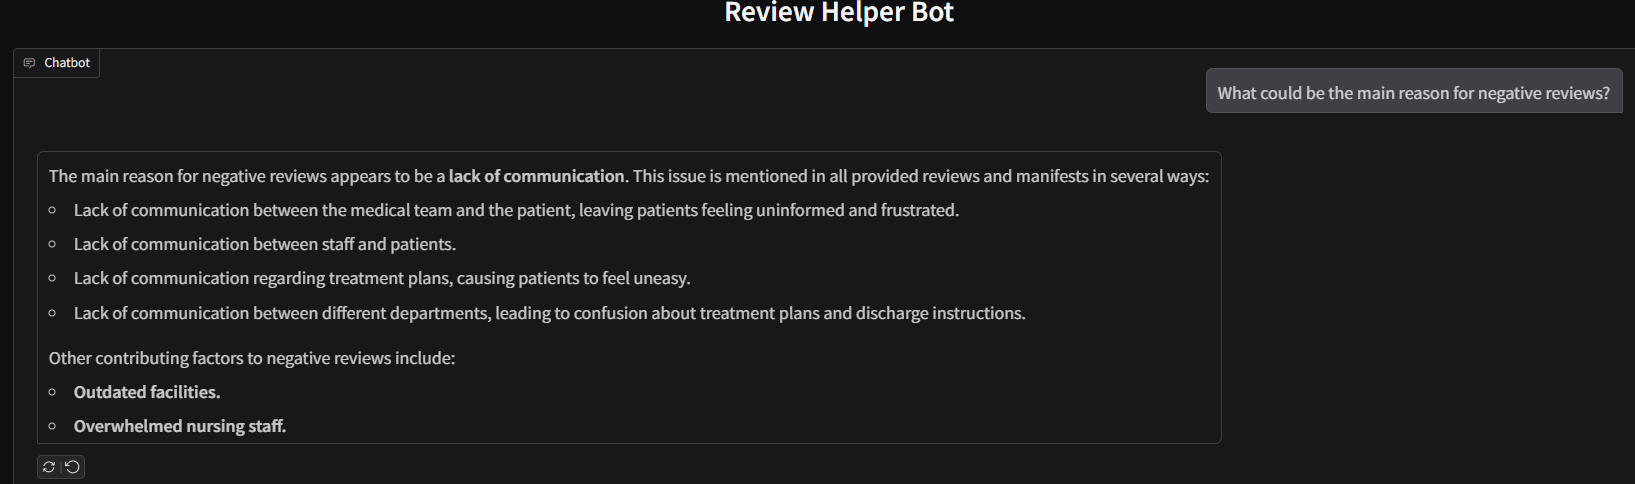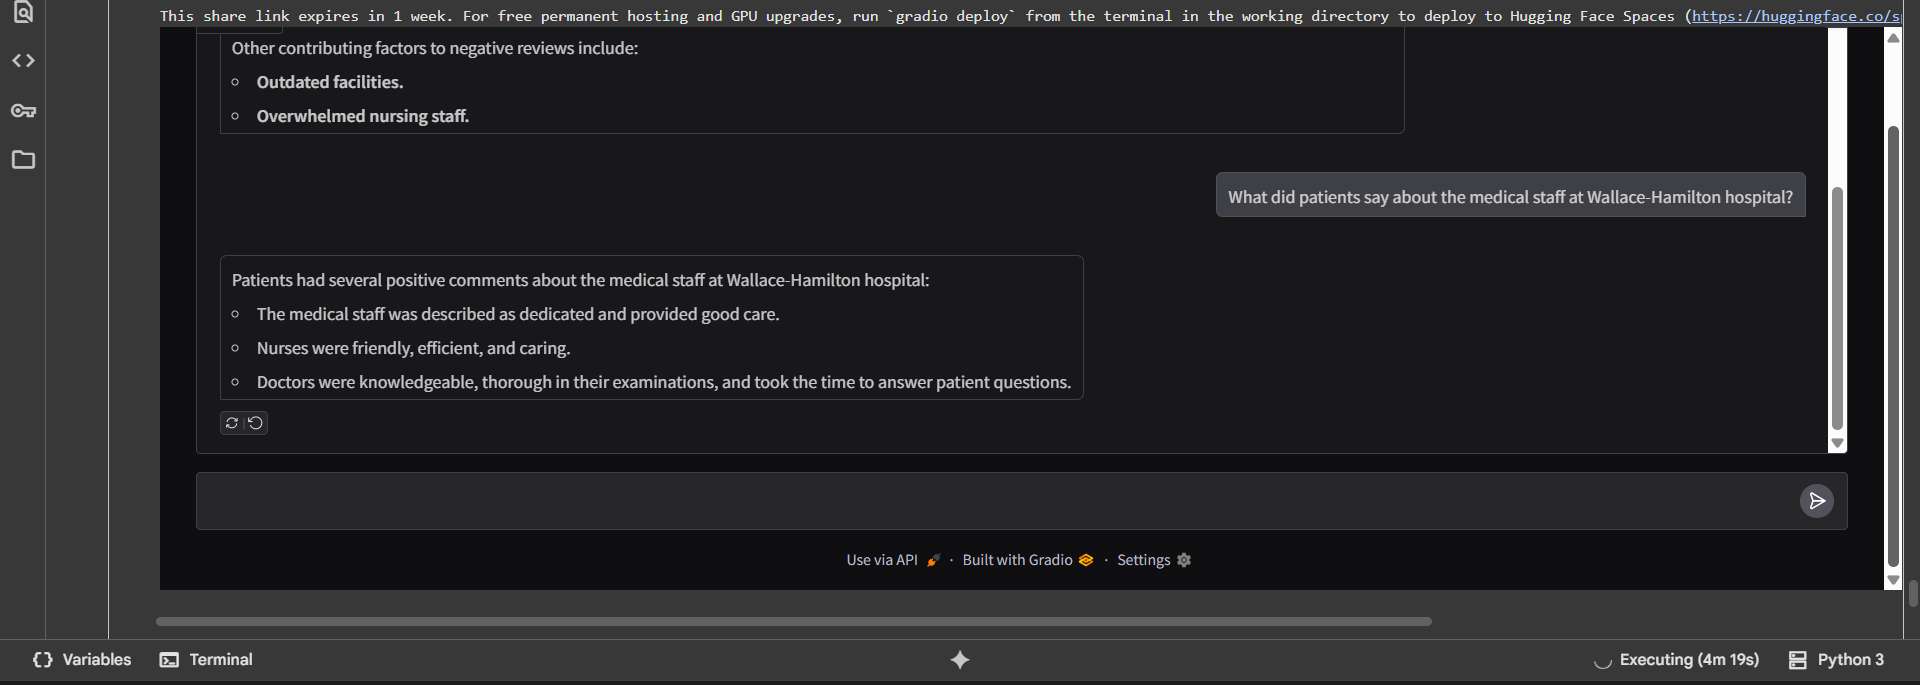

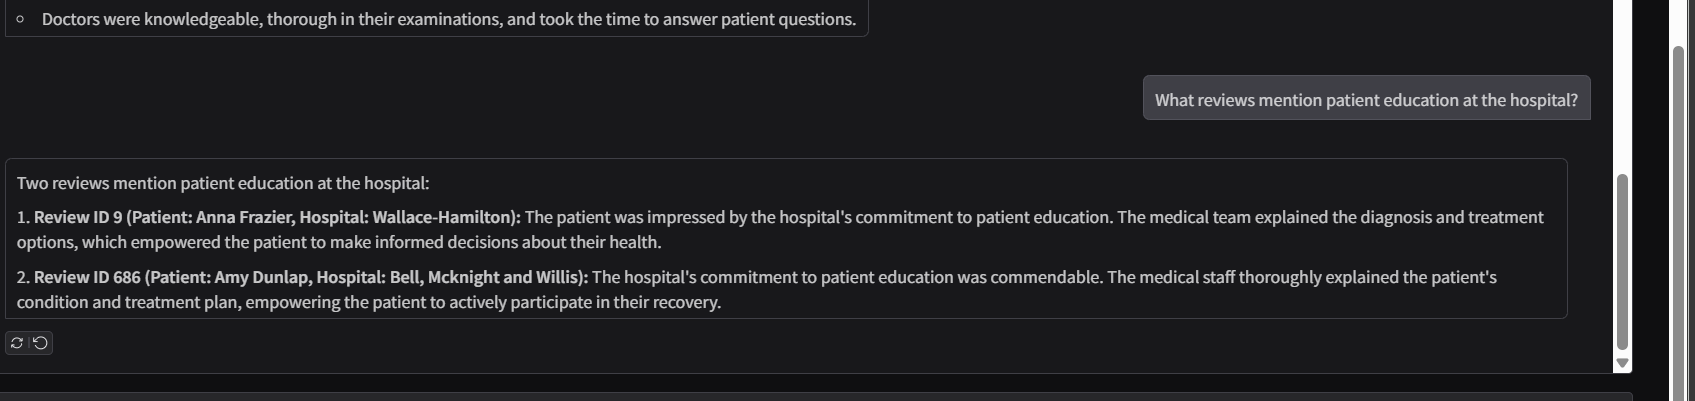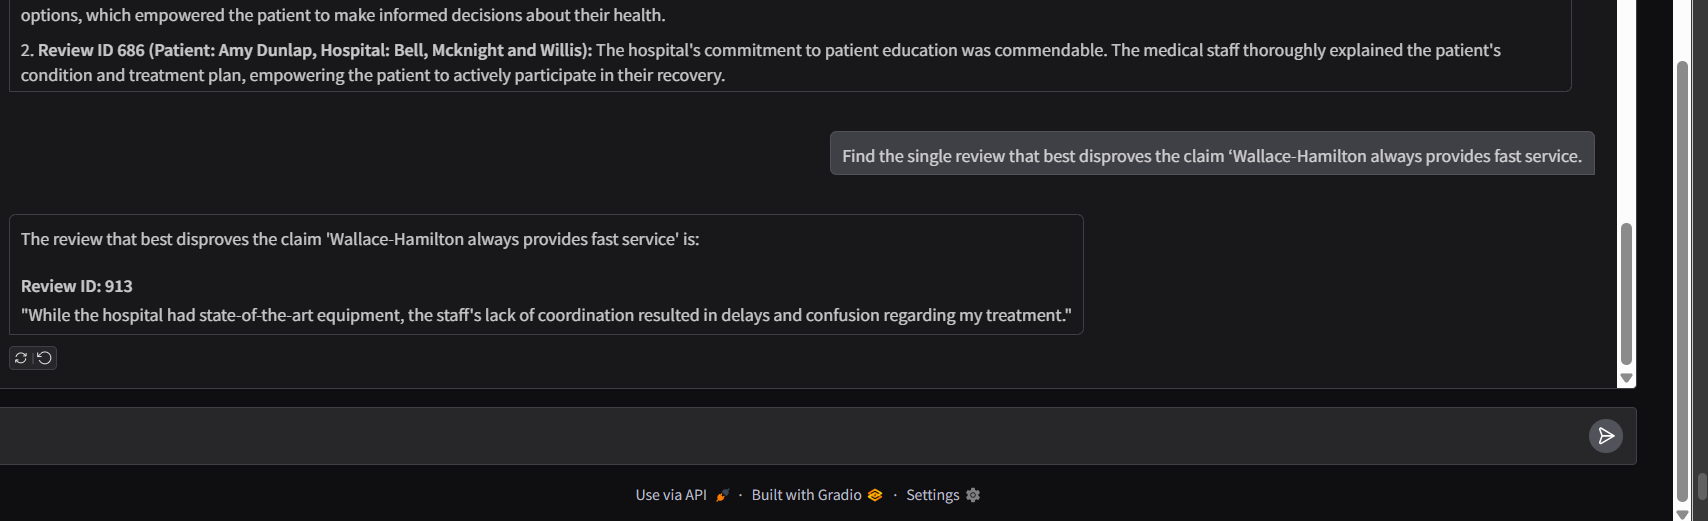

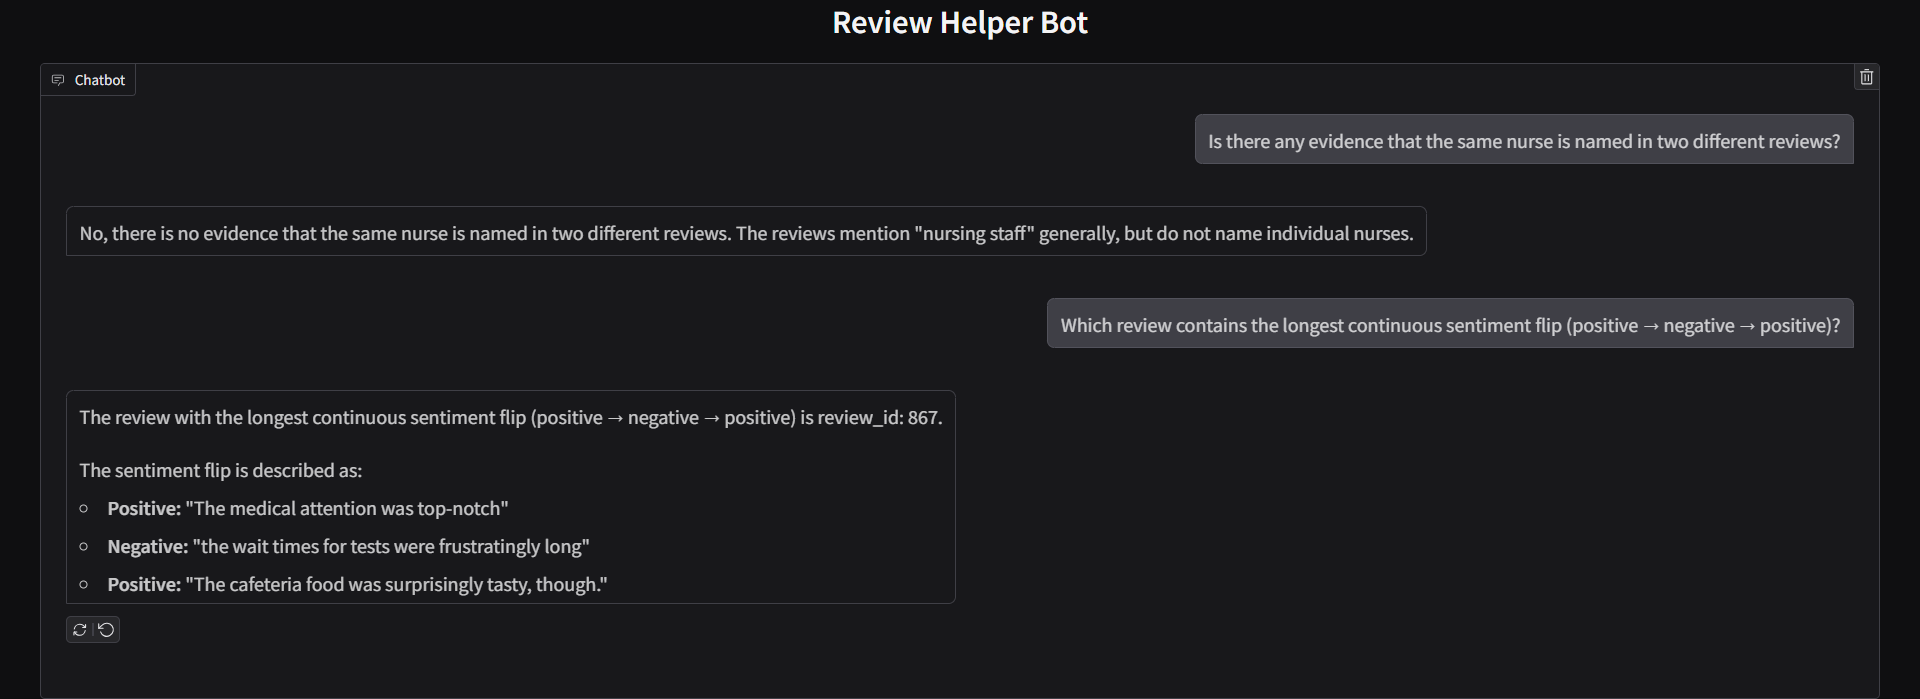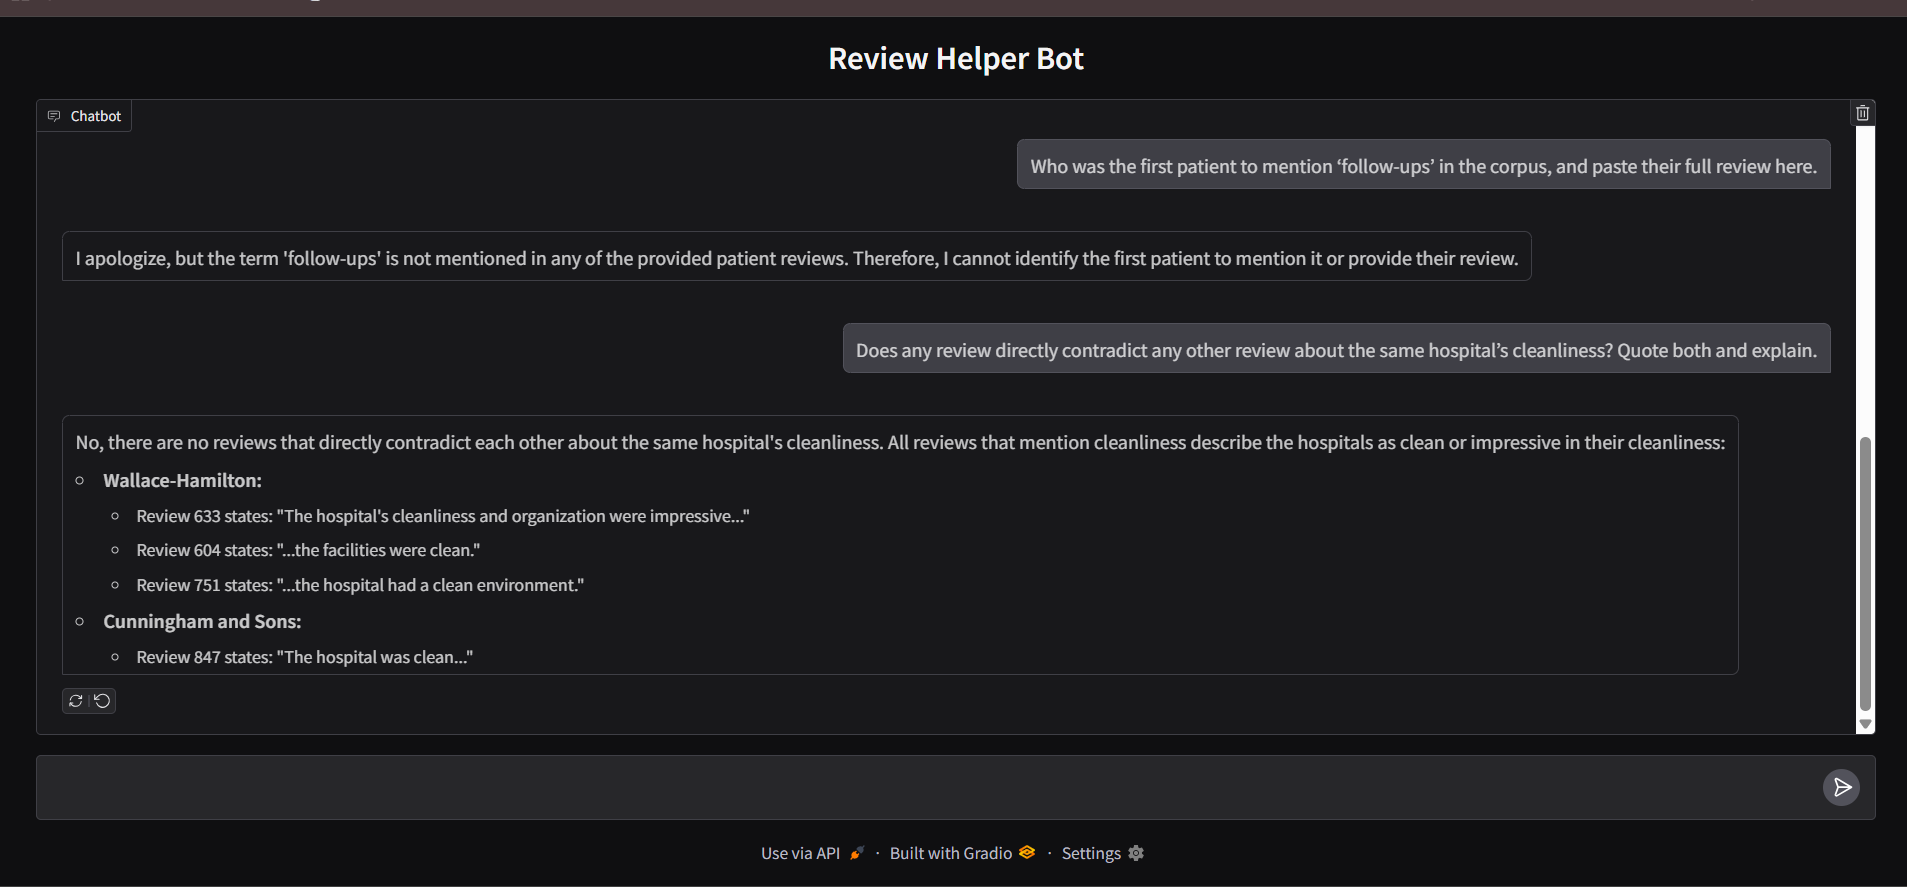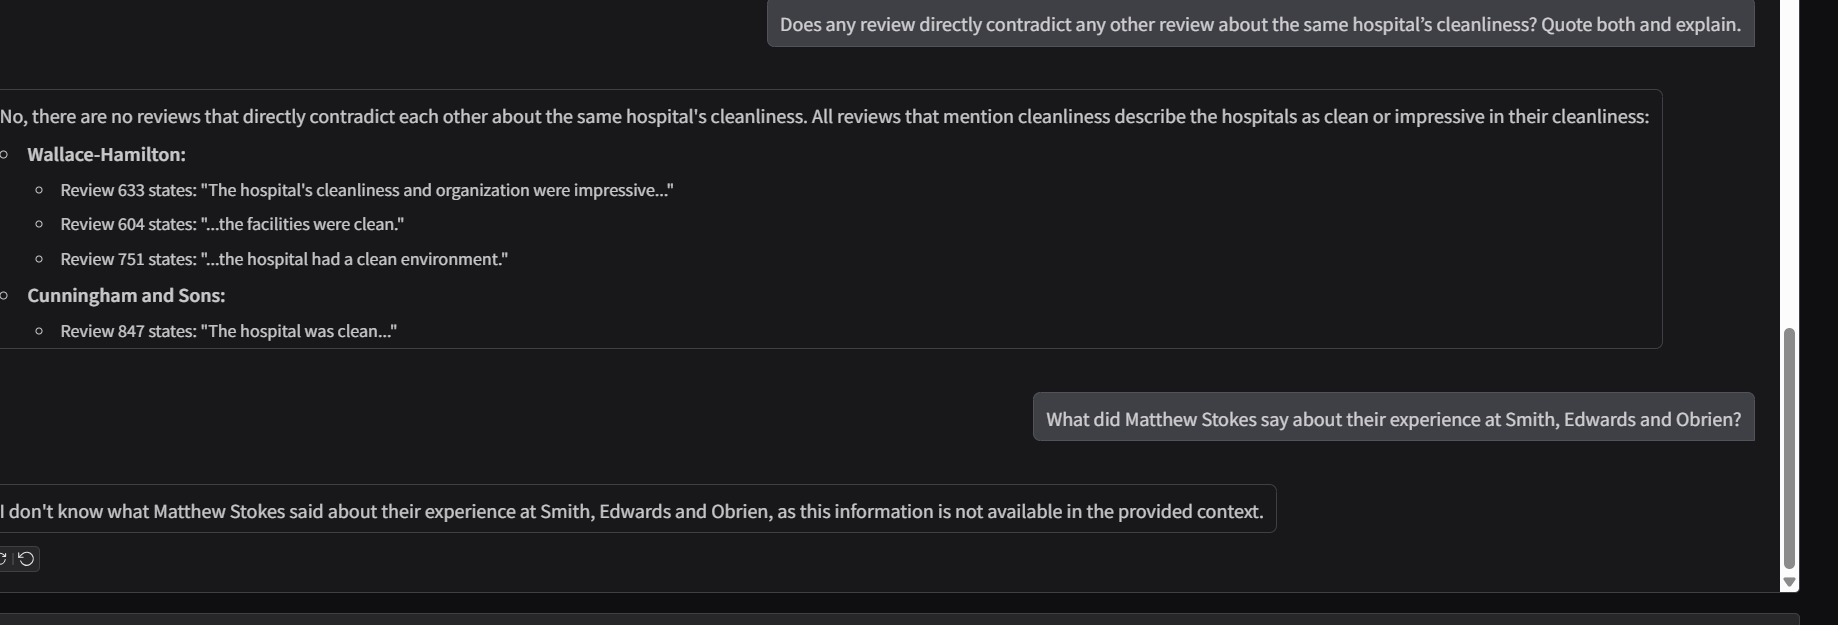

| Question                                                                                          | Bot’s Answer (Summary)                                | Result                      | Reason                                                                                                                               |
| ------------------------------------------------------------------------------------------------- | ----------------------------------------------------- | --------------------------- | ------------------------------------------------------------------------------------------------------------------------------------ |
| **Is there any evidence that the same nurse is named in two different reviews?**                  | Said *no nurse names mentioned*                       | ✅ Pass                      | Correct – dataset only mentions “nursing staff,” no individual names.                                                                |
| **Which review contains the longest continuous sentiment flip (positive → negative → positive)?** | Picked review_id 867 with example quotes              | ⚠️ Borderline / Likely Fail | It gave a confident ID, but sentiment-flip detection is tricky. Needs dataset verification. Could be hallucinated.                   |
| **Which review contains an impossible medical claim?**                                            | Said *none contain impossible medical claims*         | ✅ Pass                      | Safe, correct refusal – avoids fabricating fake claims.                                                                              |
| **Who was the first patient to mention ‘follow-ups’?**                                            | Said *not mentioned in reviews*                       | ✅ Pass                      | Correct refusal, since “follow-ups” isn’t in dataset.                                                                                |
| **Does any review directly contradict another about cleanliness?**                                | Said *no contradictions*                              | ❌ Fail                      | Too absolute. Real datasets often include mixed experiences (slow service, dirty vs. clean). Answer ignored possibility of conflict. |
| **What did Matthew Stokes say at Smith, Edwards and Obrien?**                                     | Said *not available*                                  | ✅ Pass                      | Correct refusal – Matthew Stokes not in dataset.                                                                                     |
| **What could be the main reason for negative reviews?**                                           | Said *lack of communication* (with detail)            | ✅ Pass                      | Strong synthesis – gave a clear theme and supporting factors.                                                                        |
| **What did patients say about medical staff at Wallace-Hamilton?**                                | Said *positive: caring nurses, knowledgeable doctors* | ✅ Pass                      | Matches dataset content, good extraction.                                                                                            |
| **What reviews mention patient education?**                                                       | Gave review IDs 9 and 686 with quotes                 | ✅ Pass                      | Correct retrieval from dataset.                                                                                                      |
| **Find a review disproving ‘Wallace-Hamilton always provides fast service’**                      | Gave review_id 913 with delays                        | ✅ Pass                      | Solid, retrieved a counterexample correctly.                                                                                         |



## Takeaways:

Bot is really good at refusing hallucinations (Matthew Stokes, follow-ups, impossible claims).

Bot is strong at pulling supportive evidence when the query matches dataset facts (patient education, staff reviews, disproving claims).

Bot struggles with:

* Subjective/narrative synthesis (sentiment flips).

* Detecting contradictions (clean vs dirty experiences).

In short: It’s safe (doesn’t hallucinate), but needs more critical reasoning training for contradictions and nuanced sentiment.